--- Running Small Dataset Visual Maps ---


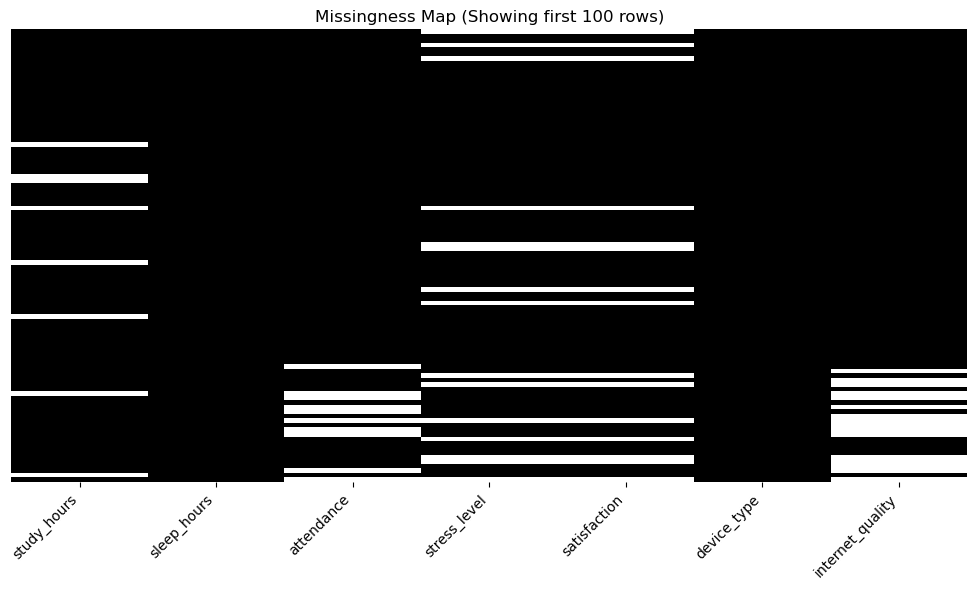

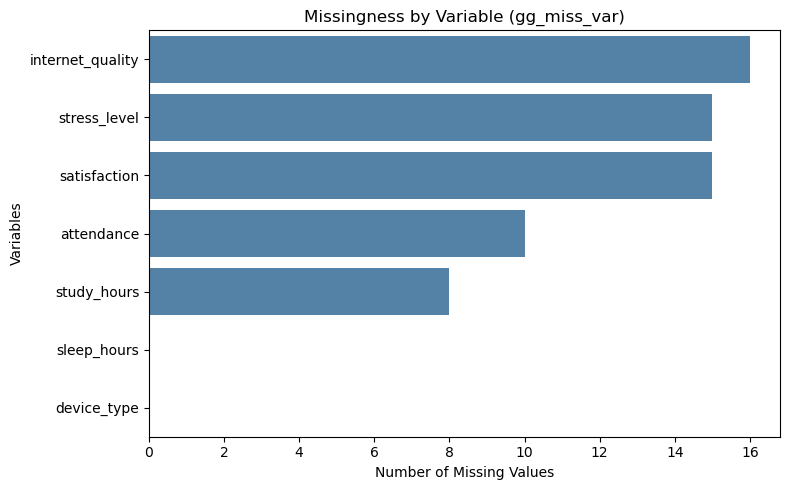


--- Running Large Dataset Macro Analysis ---


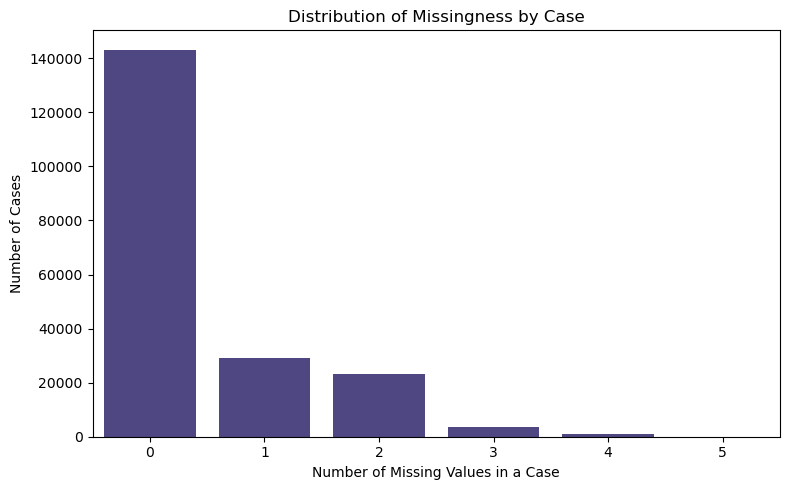

   n_miss  n_cases  pct_cases
0       0   143191    71.5955
1       1    29023    14.5115
2       2    23281    11.6405
3       3     3640     1.8200
4       4      830     0.4150
5       5       35     0.0175


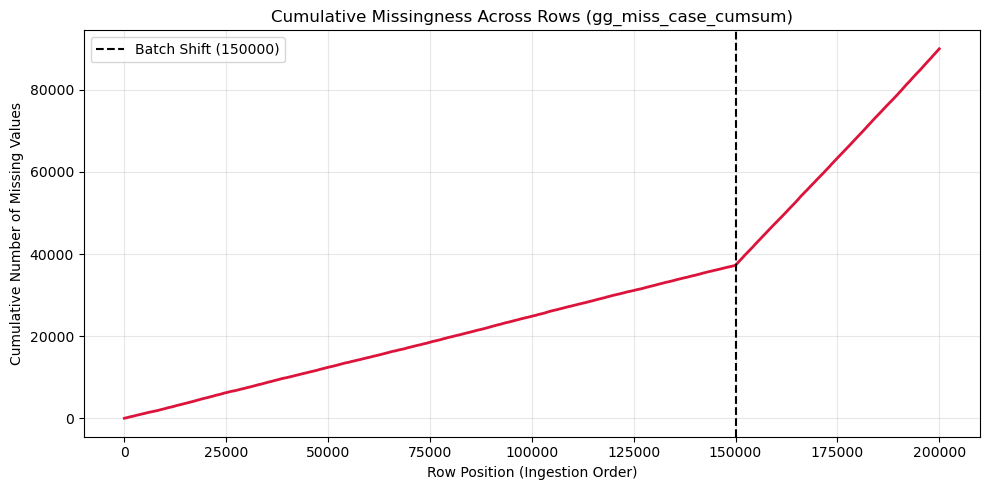

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for exact reproducibility
np.random.seed(123)

# =========================================================================
# 1. DATASET GENERATION SIMULATION (Small & Large Scale)
# =========================================================================

def generate_student_data(n, large_scale=False):
    """Generates synthetic student survey data matching the exam R layout."""
    study_hours = np.round(np.random.normal(14, 4, n), 1)
    sleep_hours = np.round(np.random.normal(6.8, 1.1, n), 1)
    attendance = np.round(np.random.uniform(60, 100, n), 1)
    stress_level = np.round(np.random.uniform(1, 5, n), 1)
    satisfaction = np.round(np.random.uniform(1, 5, n), 1)
    
    device_options = ["Laptop", "Tablet", "Phone"]
    device_type = np.random.choice(device_options, n, replace=True)
    
    iq_options = ["Poor", "Fair", "Good", "Excellent"]
    internet_quality = np.random.choice(iq_options, n, replace=True)
    
    df = pd.DataFrame({
        'study_hours': study_hours,
        'sleep_hours': sleep_hours,
        'attendance': attendance,
        'stress_level': stress_level,
        'satisfaction': satisfaction,
        'device_type': device_type,
        'internet_quality': internet_quality
    })
    
    # Inject Specific Structural Missingness Patterns
    if not large_scale:
        # Small dataset missingness rules
        df.loc[np.random.choice(n, 8, replace=False), 'study_hours'] = np.nan
        
        joint_idx = np.random.choice(n, 15, replace=False)
        df.loc[joint_idx, ['stress_level', 'satisfaction']] = np.nan
        
        late_idx = np.arange(74, 100) # Rows 75:100 in 1-indexed R
        df.loc[np.random.choice(late_idx, 10, replace=False), 'attendance'] = np.nan
        df.loc[np.random.choice(late_idx, 16, replace=False), 'internet_quality'] = np.nan
    else:
        # Large dataset missingness rules
        df.loc[np.random.choice(n, int(0.05 * n), replace=False), 'study_hours'] = np.nan
        
        joint_idx = np.random.choice(n, int(0.10 * n), replace=False)
        df.loc[joint_idx, ['stress_level', 'satisfaction']] = np.nan
        
        late_idx = np.arange(150000, n) # Rows 150001:n in 1-indexed R
        df.loc[np.random.choice(late_idx, 15000, replace=False), 'attendance'] = np.nan
        df.loc[np.random.choice(late_idx, 25000, replace=False), 'internet_quality'] = np.nan
        
    return df

small_data = generate_student_data(100, large_scale=False)
large_data = generate_student_data(200000, large_scale=True)

# =========================================================================
# 2. MISSING DATA DIAGNOSTIC FUNCTIONS (Replacing naniar & VIM)
# =========================================================================

def vis_miss_python(df, max_rows_to_plot=5000):
    """Equivalent to naniar::vis_miss(). Plots a missingness matrix map."""
    plt.figure(figsize=(10, 6))
    # Downsample if it is massive to avoid performance bottlenecks
    plot_df = df.iloc[:max_rows_to_plot].isna()
    
    sns.heatmap(plot_df, cbar=False, cmap="binary_r", yticklabels=False)
    plt.title(f"Missingness Map (Showing first {plot_df.shape[0]} rows)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def miss_var_summary_python(df):
    """Equivalent to naniar::miss_var_summary() & gg_miss_var()."""
    miss_count = df.isna().sum()
    miss_pct = (df.isna().sum() / len(df)) * 100
    
    summary = pd.DataFrame({'n_miss': miss_count, 'pct_miss': miss_pct})
    summary = summary.sort_values(by='n_miss', ascending=False).reset_index()
    summary.rename(columns={'index': 'variable'}, inplace=True)
    
    # Plotting code equivalent to gg_miss_var
    plt.figure(figsize=(8, 5))
    sns.barplot(data=summary, x='n_miss', y='variable', color='steelblue')
    plt.title("Missingness by Variable (gg_miss_var)")
    plt.xlabel("Number of Missing Values")
    plt.ylabel("Variables")
    plt.tight_layout()
    plt.show()
    
    return summary

def miss_case_summary_python(df, plot_dist=True):
    """Equivalent to naniar::miss_case_summary(), miss_case_table(), & gg_miss_case()."""
    n_miss_per_case = df.isna().sum(axis=1)
    
    # Calculate aggregate frequency table
    case_dist = n_miss_per_case.value_counts().reset_index()
    case_dist.columns = ['n_miss', 'n_cases']
    case_dist['pct_cases'] = (case_dist['n_cases'] / len(df)) * 100
    case_dist = case_dist.sort_values(by='n_miss').reset_index(drop=True)
    
    if plot_dist:
        plt.figure(figsize=(8, 5))
        sns.barplot(data=case_dist, x='n_miss', y='n_cases', color='darkslateblue')
        plt.title("Distribution of Missingness by Case")
        plt.xlabel("Number of Missing Values in a Case")
        plt.ylabel("Number of Cases")
        plt.tight_layout()
        plt.show()
        
    return case_dist

def gg_miss_case_cumsum_python(df, xintercept=None):
    """Equivalent to naniar::gg_miss_case_cumsum(). Detects structural changes."""
    n_miss_per_case = df.isna().sum(axis=1)
    cumsum_miss = n_miss_per_case.cumsum()
    
    plt.figure(figsize=(10, 5))
    plt.plot(cumsum_miss.index, cumsum_miss.values, color='crimson', lw=2)
    
    if xintercept is not None:
        plt.axvline(x=xintercept, color='black', linestyle='--', label=f'Batch Shift ({xintercept})')
        plt.legend()
        
    plt.title("Cumulative Missingness Across Rows (gg_miss_case_cumsum)")
    plt.xlabel("Row Position (Ingestion Order)")
    plt.ylabel("Cumulative Number of Missing Values")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# =========================================================================
# 3. RUN DIAGNOSTIC PIPELINES
# =========================================================================

print("--- Running Small Dataset Visual Maps ---")
vis_miss_python(small_data)
small_vars = miss_var_summary_python(small_data)

print("\n--- Running Large Dataset Macro Analysis ---")
large_cases = miss_case_summary_python(large_data, plot_dist=True)
print(large_cases)

# Detect structural batch changes in large dataset ingestion (Shift at row index 150,000)
gg_miss_case_cumsum_python(large_data, xintercept=150000)


--- Structural Metadata Comparison ---
       Method  Rows  Remaining_Missing
     Original   100                 64
Complete-Case    66                  0
  Median/Mode   100                  0
          kNN   100                  0
         MICE   100                  0

--- Shift in Means Analysis Across Frameworks ---
                  Method  study_hours  sleep_hours  attendance  stress_level  satisfaction
Original (observed only)    14.275000        6.778   79.323333      3.016471      2.963529
           Complete-Case    14.810606        6.800   78.593939      3.053030      2.933333
             Median/Mode    14.253000        6.778   79.221000      2.999000      2.939000
                     kNN    14.197800        6.778   79.389800      3.039000      3.034000
                    MICE    14.300162        6.778   79.236480      3.007609      2.965584


/tmp/ipykernel_11535/1107892211.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Method', y='study_hours', palette='Set2')


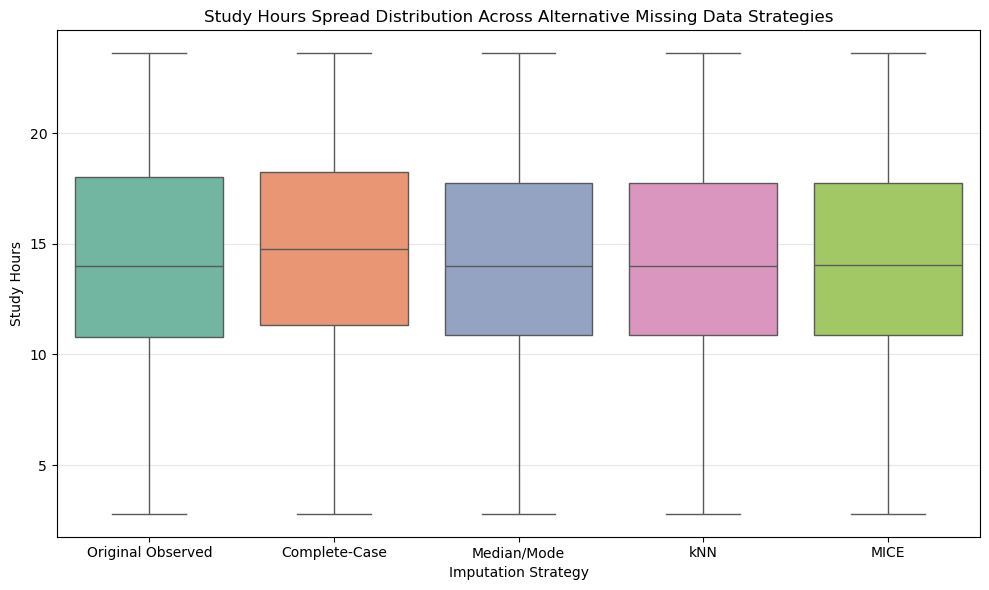

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn Imputation Infrastructure
from sklearn.experimental import enable_iterative_imputer  # Explicitly enables MICE
from sklearn.impute import KNNImputer, IterativeImputer

np.random.seed(123)
# Base small dataset generation from Section 1
student_survey = generate_student_data(100, large_scale=False)

# =========================================================================
# METHOD 1: COMPLETE-CASE ANALYSIS (Listwise Deletion)
# =========================================================================
student_cc = student_survey.dropna().copy()

# =========================================================================
# METHOD 2: SIMPLE GLOBAL MEDIAN / MODE IMPUTATION
# =========================================================================
student_simple = student_survey.copy()

for col in student_simple.columns:
    if pd.api.types.is_numeric_dtype(student_simple[col]):
        # Numeric fields get the series median
        median_val = student_simple[col].median()
        student_simple[col] = student_simple[col].fillna(median_val)
    else:
        # Categorical fields get the most frequent value (mode)
        mode_val = student_simple[col].mode()[0]
        student_simple[col] = student_simple[col].fillna(mode_val)

# =========================================================================
# CATEGORICAL CATEGORY PREPROCESSING FOR SKLEARN IMPUTERS (kNN & MICE)
# =========================================================================
# Scikit-Learn handles tabular structures as float arrays. We must parse categories to numeric codes,
# keeping missing values intact, and decode back to text strings post-imputation.

student_encoded = student_survey.copy()

# 1. Define explicit ordinal structural maps preserving NaNs
device_map = {"Laptop": 0.0, "Tablet": 1.0, "Phone": 2.0}
iq_map = {"Poor": 0.0, "Fair": 1.0, "Good": 2.0, "Excellent": 3.0}

inv_device_map = {v: k for k, v in device_map.items()}
inv_iq_map = {v: k for k, v in iq_map.items()}

# 2. Perform safe encoding transformations
student_encoded['device_type'] = student_encoded['device_type'].map(device_map)
student_encoded['internet_quality'] = student_encoded['internet_quality'].map(iq_map)

# =========================================================================
# METHOD 3: k-NEAREST NEIGHBORS (kNN) IMPUTATION
# =========================================================================
knn_engine = KNNImputer(n_neighbors=5)
knn_raw = knn_engine.fit_transform(student_encoded)
student_knn = pd.DataFrame(knn_raw, columns=student_encoded.columns)

# Safely decode back to original text strings using rounded nearest indices
student_knn['device_type'] = student_knn['device_type'].round().clip(0, 2).map(inv_device_map)
student_knn['internet_quality'] = student_knn['internet_quality'].round().clip(0, 3).map(inv_iq_map)

# =========================================================================
# METHOD 4: MICE (MULTIPLE IMPUTATION BY CHAINED EQUATIONS)
# =========================================================================
# sklearn's IterativeImputer replicates R's mice package workflow sequentially
mice_engine = IterativeImputer(max_iter=10, random_state=123)
mice_raw = mice_engine.fit_transform(student_encoded)
student_mice = pd.DataFrame(mice_raw, columns=student_encoded.columns)

# Safely decode MICE arrays back to categorical factors
student_mice['device_type'] = student_mice['device_type'].round().clip(0, 2).map(inv_device_map)
student_mice['internet_quality'] = student_mice['internet_quality'].round().clip(0, 3).map(inv_iq_map)

# =========================================================================
# EVALUATION METRIC COMPARISONS & EXAMINATION VERIFICATION
# =========================================================================

# --- Summary A: Sample Sizes and Residual Missingness Check ---
compare_missing = pd.DataFrame({
    'Method': ['Original', 'Complete-Case', 'Median/Mode', 'kNN', 'MICE'],
    'Rows': [len(student_survey), len(student_cc), len(student_simple), len(student_knn), len(student_mice)],
    'Remaining_Missing': [df.isna().sum().sum() for df in [student_survey, student_cc, student_simple, student_knn, student_mice]]
})
print("\n--- Structural Metadata Comparison ---")
print(compare_missing.to_string(index=False))

# --- Summary B: Evaluate Shifts in Central Tendencies (Means) ---
numeric_cols = ['study_hours', 'sleep_hours', 'attendance', 'stress_level', 'satisfaction']

stats_summary = pd.DataFrame({
    'Original (observed only)': student_survey[numeric_cols].mean(),
    'Complete-Case': student_cc[numeric_cols].mean(),
    'Median/Mode': student_simple[numeric_cols].mean(),
    'kNN': student_knn[numeric_cols].mean(),
    'MICE': student_mice[numeric_cols].mean()
}).T.reset_index().rename(columns={'index': 'Method'})

print("\n--- Shift in Means Analysis Across Frameworks ---")
print(stats_summary.to_string(index=False))

# --- Summary C: Visual Distribution Stability Comparison (Boxplot) ---
# Prepare the individual frames for seaborn plotting
plot_frames = [
    student_survey[['study_hours']].dropna().assign(Method='Original Observed'),
    student_cc[['study_hours']].assign(Method='Complete-Case'),
    student_simple[['study_hours']].assign(Method='Median/Mode'),
    student_knn[['study_hours']].assign(Method='kNN'),
    student_mice[['study_hours']].assign(Method='MICE')
]
plot_df = pd.concat(plot_frames, axis=0)

plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_df, x='Method', y='study_hours', palette='Set2')
plt.title("Study Hours Spread Distribution Across Alternative Missing Data Strategies")
plt.xlabel("Imputation Strategy")
plt.ylabel("Study Hours")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [2]:
import collections
import collections.abc
# Inject the missing aliases back into the collections module for backwards compatibility
collections.Iterable = collections.abc.Iterable
collections.Mapping = collections.abc.Mapping
collections.MutableMapping = collections.abc.MutableMapping
import networkx as nx
from causalgraphicalmodels import CausalGraphicalModel

# Helper function to replicate R's ggdag_parents() functionality programmatically
def get_node_parents(model, node):
    """Returns the immediate parents of a node from a CausalGraphicalModel."""
    return list(model.dag.predecessors(node))

def print_break(title):
    print(f"\n{'='*30}\n{title.upper()}\n{'='*30}")


# =========================================================================
# PART 1: THE CANONICAL ELEMENTAL TRIADS (The Three Basic Structures)
# Files Consolidated: 'The three structures.R' & 'd-separation.R'
# =========================================================================
print_break("Part 1: The Three Core Structural Shapes & d-Separation")

# 1. Chain Structure (X -> M -> Y) - Mediation Pathway
chain = CausalGraphicalModel(
    nodes=["X", "M", "Y"],
    edges=[("X", "M"), ("M", "Y")]
)
print("Chain - Is X & Y d-separated unconditionally?", chain.is_d_separated("X", "Y", {}))        # False (Path open)
print("Chain - Is X & Y d-separated conditioning on M?", chain.is_d_separated("X", "Y", {"M"}))  # True (Blocked)

# 2. Fork Structure (X <- C -> Y) - Confounding / Common Cause Pathway
fork = CausalGraphicalModel(
    nodes=["X", "C", "Y"],
    edges=[("C", "X"), ("C", "Y")]
)
print("Fork - Is X & Y d-separated unconditionally?", fork.is_d_separated("X", "Y", {}))         # False (Path open)
print("Fork - Is X & Y d-separated conditioning on C?", fork.is_d_separated("X", "Y", {"C"}))   # True (Blocked)

# 3. Collider Structure (X -> S <- Y) - Common Effect Pathway
collider = CausalGraphicalModel(
    nodes=["X", "S", "Y"],
    edges=[("X", "S"), ("Y", "S")]
)
print("Collider - Is X & Y d-separated unconditionally?", collider.is_d_separated("X", "Y", {}))       # True (Naturally blocked)
print("Collider - Is X & Y d-separated conditioning on S?", collider.is_d_separated("X", "Y", {"S"})) # False (Opened!)


# =========================================================================
# PART 2: CAUSAL BACKDOOR ADJUSTMENT SETS (Backdoor Criterion)
# Files Consolidated: 'Mini-case A.R' & 'CS3dag.R'
# =========================================================================
print_break("Part 2: Identifying Backdoor Adjustment Sets")

# Mini-Case A: Health & Blood Pressure
# Exposure: Exercise, Outcome: BloodPressure
health_dag = CausalGraphicalModel(
    nodes=["Exercise", "BloodPressure", "HealthConsciousness", "DietQuality"],
    edges=[
        ("HealthConsciousness", "Exercise"),
        ("HealthConsciousness", "DietQuality"),
        ("DietQuality", "BloodPressure"),
        ("Exercise", "BloodPressure")
    ]
)
print("Health DAG - Backdoor Adjustment Sets for Exercise -> BloodPressure:")
print(health_dag.get_all_backdoor_adjustment_sets("Exercise", "BloodPressure")) 
# Expected sets: {{'HealthConsciousness'}, {'DietQuality'}, {'DietQuality', 'HealthConsciousness'}}

# CS3dag: Marketing Effectiveness Analytics
# Exposure: Emails, Outcome: Spending
marketing_dag = CausalGraphicalModel(
    nodes=["Emails", "Spending", "CustomerLoyalty"],
    edges=[
        ("CustomerLoyalty", "Emails"),
        ("CustomerLoyalty", "Spending"),
        ("Emails", "Spending")
    ]
)
print("\nMarketing DAG - Backdoor Adjustment Sets for Emails -> Spending:")
print(marketing_dag.get_all_backdoor_adjustment_sets("Emails", "Spending"))
# Expected sets: {{'CustomerLoyalty'}}


# =========================================================================
# PART 3: ADVANCED STRUCTURAL CONSTRAINTS & BIAS RULES
# Files Consolidated: 'CS2dag.R' & 'CS4dag.R'
# =========================================================================
print_break("Part 3: Mediation Inferences & Collider Selection Bias")

# CS2dag: Educational Performance Mediation Model
# Exposure: Tutoring, Outcome: ExamScore
chain_dag = CausalGraphicalModel(
    nodes=["Tutoring", "Homework", "ExamScore"],
    edges=[
        ("Tutoring", "Homework"),
        ("Homework", "ExamScore"),
        ("Tutoring", "ExamScore")
    ]
)
# Checking if controlling for the mediator blocks the path completely
print("Is Tutoring d-separated from ExamScore when holding Homework fixed?")
print(chain_dag.is_d_separated("Tutoring", "ExamScore", {"Homework"})) 
# False (Because there is still a direct unblocked causal arrow: Tutoring -> ExamScore)

# CS4dag: University Selection Bias (Collider Phenomenon)
# Exposure: TestScore, Outcome: Extracurriculars
collider_dag = CausalGraphicalModel(
    nodes=["TestScore", "Extracurriculars", "Admission"],
    edges=[
        ("TestScore", "Admission"),
        ("Extracurriculars", "Admission")
    ]
)
print("\nCollider Bias Verification:")
print("Are Test Scores & Extracurriculars independent in general population?", 
      collider_dag.is_d_separated("TestScore", "Extracurriculars", {})) # True
print("Are they conditionally linked within accepted University Students (Admission)?", 
      collider_dag.is_d_separated("TestScore", "Extracurriculars", {"Admission"})) # False (Path Opened!)


# =========================================================================
# PART 4: COMPLEX NETWORKS & STRUCTURAL GRAPH QUERIES
# Files Consolidated: 'Intro to DAGs Basic DAGs and Parents.R', 'CS1dag.R', 
#                     'Intro to DAG - Ex1 A1.R', & 'Intro to DAG - Ex1 A2.R'
# =========================================================================
print_break("Part 4: Multi-Variable Graphical Infrastructure & Structural Queries")

# Model A: The Academic Network Model
academic_dag = CausalGraphicalModel(
    nodes=["PriorAbility", "Motivation", "Tutoring", "Homework", "ExamScore"],
    edges=[
        ("PriorAbility", "Tutoring"),
        ("PriorAbility", "ExamScore"),
        ("Motivation", "Tutoring"),
        ("Motivation", "ExamScore"),
        ("Tutoring", "Homework"),
        ("Homework", "ExamScore"),
        ("Tutoring", "ExamScore")
    ]
)
print("Academic Model Diagnostics:")
print("Immediate parents triggering 'ExamScore':", get_node_parents(academic_dag, "ExamScore"))
print("Immediate parents triggering 'Homework':", get_node_parents(academic_dag, "Homework"))
print("Required Adjustment set to find the true causal effect of Tutoring -> ExamScore:")
print(academic_dag.get_all_backdoor_adjustment_sets("Tutoring", "ExamScore"))

# Model B: Flat Sleep vs GPA Structure (Ex1 A1 / CS1dag)
sleep_dag_flat = CausalGraphicalModel(
    nodes=["sleep", "GPA", "stress", "work_hours", "time_management"],
    edges=[
        ("stress", "sleep"), ("stress", "GPA"),
        ("work_hours", "sleep"), ("work_hours", "GPA"),
        ("time_management", "sleep"), ("time_management", "GPA"),
        ("sleep", "GPA")
    ]
)
print("\nFlat Sleep Model Backdoor Adjustments:")
print(sleep_dag_flat.get_all_backdoor_adjustment_sets("sleep", "GPA"))

# Model C: Fully Hierarchical/Structured Sleep vs GPA System (Ex1 A2)
sleep_dag_structured = CausalGraphicalModel(
    nodes=["sleep", "GPA", "time_management", "work_hours", "stress"],
    edges=[
        ("time_management", "sleep"),
        ("time_management", "GPA"),
        ("time_management", "work_hours"),
        ("work_hours", "stress"),
        ("stress", "sleep"),
        ("stress", "GPA"),
        ("sleep", "GPA")
    ]
)
print("\nStructured Sleep Model Diagnostics:")
print("Immediate structural parents of 'GPA':", get_node_parents(sleep_dag_structured, "GPA"))
print("Optimized Backdoor Adjustment set for sleep -> GPA:")
print(sleep_dag_structured.get_all_backdoor_adjustment_sets("sleep", "GPA"))

# VISUALIZATION TRICK: To plot these inside your notebook or export them using graphviz:
# sleep_dag_structured.draw().render("sleep_dag", format="png")


PART 1: THE THREE CORE STRUCTURAL SHAPES & D-SEPARATION
Chain - Is X & Y d-separated unconditionally? False
Chain - Is X & Y d-separated conditioning on M? True
Fork - Is X & Y d-separated unconditionally? False
Fork - Is X & Y d-separated conditioning on C? True
Collider - Is X & Y d-separated unconditionally? True
Collider - Is X & Y d-separated conditioning on S? False

PART 2: IDENTIFYING BACKDOOR ADJUSTMENT SETS
Health DAG - Backdoor Adjustment Sets for Exercise -> BloodPressure:
frozenset({frozenset({'DietQuality'}), frozenset({'HealthConsciousness'}), frozenset({'DietQuality', 'HealthConsciousness'})})

Marketing DAG - Backdoor Adjustment Sets for Emails -> Spending:
frozenset({frozenset({'CustomerLoyalty'})})

PART 3: MEDIATION INFERENCES & COLLIDER SELECTION BIAS
Is Tutoring d-separated from ExamScore when holding Homework fixed?
False

Collider Bias Verification:
Are Test Scores & Extracurriculars independent in general population? True
Are they conditionally linked within a

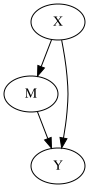

'my_dag.png'

In [ ]:
import collections
import collections.abc
# Python 3.13 Compatibility Fix
collections.Iterable = collections.abc.Iterable
collections.Mapping = collections.abc.Mapping
collections.MutableMapping = collections.abc.MutableMapping

from causalgraphicalmodels import CausalGraphicalModel

# 1. Define your DAG structure
dag = CausalGraphicalModel(
    nodes=["X", "M", "Y"],
    edges=[
        ("X", "M"), 
        ("M", "Y"),
                ("X", "Y"), 

    ]
)

# 2. Draw the graph
# If using a Jupyter Notebook, simply run this line to see it inline:
graph = dag.draw()
display(graph) # Or just 'graph' at the end of a cell

# 3. Save the diagram to a file (PNG or PDF)
# This saves 'my_dag.png' in your current working directory
dag.draw().render(filename="my_dag", format="png", cleanup=True)

### Time Series 


In [ ]:
import pandas as pd
import numpy as np

# Set seed for reproducible results during study
np.random.seed(42)

# ==========================================
# 1. Mock Data for `a10` (Drug Sales)
# Characteristics: Monthly, strong upward trend, heavy annual seasonality
# ==========================================
dates_monthly = pd.date_range(start="2000-01-01", end="2008-12-01", freq="MS")
n_months = len(dates_monthly)

# Trend + Sine wave for yearly seasonality + random noise
trend_a10 = np.linspace(5, 25, n_months)
seasonal_a10 = 4 * np.sin(2 * np.pi * dates_monthly.month / 12)
noise_a10 = np.random.normal(0, 1, n_months)

a10_mock = pd.DataFrame({
    'Date': dates_monthly,
    'Cost': trend_a10 + seasonal_a10 + noise_a10
})


# ==========================================
# 2. Mock Data for `ansett` (Airlines Data)
# Characteristics: Multi-category groupings with independent metrics
# ==========================================
dates_weekly = pd.date_range(start="2002-01-01", end="2004-12-31", freq="W")
n_weeks = len(dates_weekly)

ansett_list = []
categories = [
    ("MEL-SYD", "Economy"), ("MEL-SYD", "First"), 
    ("SYD-BNE", "Economy"), ("SYD-BNE", "First")
]

for airport, air_class in categories:
    base_passengers = 15000 if air_class == "Economy" else 2000
    # Add random walk or fluctuations
    passengers = base_passengers + np.cumsum(np.random.normal(0, 200, n_weeks))
    
    df_temp = pd.DataFrame({
        'Date': dates_weekly,
        'Airports': airport,
        'Class': air_class,
        'Passengers': np.clip(passengers, 500, None) # Don't let passengers drop below 500
    })
    ansett_list.append(df_temp)

ansett_mock = pd.concat(ansett_list, ignore_index=True)


# ==========================================
# 3. Mock Data for `vic_elec` (Electricity vs Temp)
# Characteristics: High-frequency tracking, strong physical relationship
# ==========================================
dates_daily = pd.date_range(start="2014-01-01", end="2014-12-31", freq="D")
n_days = len(dates_daily)

# Generate temperatures fluctuating realistically throughout a year
temperature = 20 + 10 * np.sin(2 * np.pi * dates_daily.dayofyear / 365) + np.random.normal(0, 3, n_days)
# Demand goes up when it is exceptionally hot or cold (U-shaped/Quadratic relationship)
demand = 15 + 0.05 * (temperature - 18)**2 + np.random.normal(0, 1.5, n_days)

vic_elec_mock = pd.DataFrame({
    'Date': dates_daily,
    'Temperature': temperature,
    'Demand': demand
})


# ==========================================
# 4. Mock Data for `tourism` & `holidays`
# Characteristics: Panel/Longitudinal data tracking regions across quarters
# ==========================================
# Corrected standard quarters from 2000 to 2010 to fit within Pandas 'ns' bounds
dates_quarterly = pd.date_range(start="2000-01-01", end="2010-10-01", freq="QS")
n_quarters = len(dates_quarterly)

tourism_list = []
states = ["NSW", "VIC", "QLD", "SA", "WA", "TAS", "NT", "ACT"]

for state in states:
    # Give every state a slightly different structural trend/mean for panel tracking
    base_trips = np.random.randint(200, 800)
    seasonal_trips = 150 * np.sin(2 * np.pi * dates_quarterly.quarter / 4)
    trips = base_trips + seasonal_trips + np.random.normal(0, 40, n_quarters)
    
    df_temp = pd.DataFrame({
        'Date': dates_quarterly,
        'State': state,
        'Trips': np.clip(trips, 10, None)
    })
    tourism_list.append(df_temp)

tourism_mock = pd.concat(tourism_list, ignore_index=True)

# Also create the 'holidays' dataframe expected by snippet 4
holidays_mock = tourism_mock.copy()
# ==========================================
# 5. Mock Data for `aus_production` & White Noise
# Characteristics: Regular quarterly cycles & purely stochastic baselines
# ==========================================
# Quarterly timeline spanning years 1995 to 2010
dates_prod = pd.date_range(start="1995-01-01", end="2010-10-01", freq="QS")
n_prod = len(dates_prod)

# Beer production has stable, visible structural patterns (quarterly cycles)
beer_trend = np.linspace(400, 450, n_prod)
beer_seasonal = 50 * np.sin(2 * np.pi * dates_prod.quarter / 4)
beer_noise = np.random.normal(0, 8, n_prod)

aus_production_mock = pd.DataFrame({
    'Date': dates_prod,
    'Beer': beer_trend + beer_seasonal + beer_noise,
    'wn': np.random.normal(loc=0, scale=1, size=n_prod) # Pure mathematical White Noise
})

# ==========================================
# Print shapes to verify success
# ==========================================
print("Mock Data Generation Complete!")
print(f"a10_mock shape: {a10_mock.shape} -> Expected Columns: ['Date', 'Cost']")
print(f"ansett_mock shape: {ansett_mock.shape} -> Expected Columns: ['Date', 'Airports', 'Class', 'Passengers']")
print(f"vic_elec_mock shape: {vic_elec_mock.shape} -> Expected Columns: ['Date', 'Temperature', 'Demand']")
print(f"tourism_mock shape: {tourism_mock.shape} -> Expected Columns: ['Date', 'State', 'Trips']")
print(f"aus_production_mock shape: {aus_production_mock.shape} -> Expected Columns: ['Date', 'Beer', 'wn']")
df = ansett_mock

Mock Data Generation Complete!
a10_mock shape: (108, 2) -> Expected Columns: ['Date', 'Cost']
ansett_mock shape: (624, 4) -> Expected Columns: ['Date', 'Airports', 'Class', 'Passengers']
vic_elec_mock shape: (365, 3) -> Expected Columns: ['Date', 'Temperature', 'Demand']
tourism_mock shape: (352, 3) -> Expected Columns: ['Date', 'State', 'Trips']
aus_production_mock shape: (64, 3) -> Expected Columns: ['Date', 'Beer', 'wn']


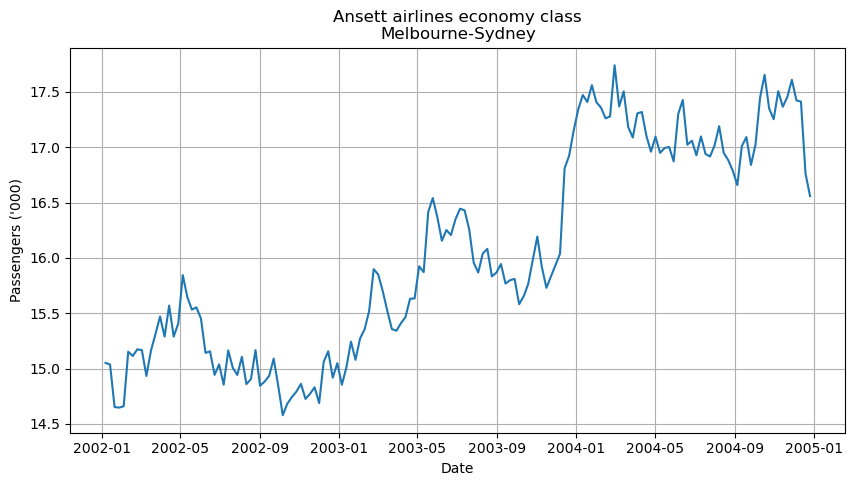

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' has a column named 'Date' which has been converted to datetime:
# df['Date'] = pd.to_datetime(df['Date'])

# 1. Filtering, Mutating (Scaling), and Time Plotting (Replicates Snippet 1)
# R: melsyd_economy <- ansett |> filter(Airports == "MEL-SYD", Class == "Economy") |> mutate(Passengers = Passengers/1000)
filtered_df = df[(df['Airports'] == 'MEL-SYD') & (df['Class'] == 'Economy')].copy()
filtered_df['Passengers_K'] = filtered_df['Passengers'] / 1000

plt.figure(figsize=(10, 5))
plt.plot(filtered_df['Date'], filtered_df['Passengers_K'], label='Economy')
plt.title("Ansett airlines economy class\nMelbourne-Sydney")
plt.xlabel("Date")
plt.ylabel("Passengers ('000)")
plt.grid(True)
plt.show()

# 2. Filtering by Temporal Attributes (Replicates Snippet 5 & 8)
# R: filter(year(Time) == 2014)  OR  filter(year(Quarter) >= 2000)
df_2014 = df[df['Date'].dt.year == 2014]
df_recent = df[df['Date'].dt.year >= 2000]
df = tourism_mock
# 3. Aggregation & Feature Pivoting (Replicates Snippet 6 & 7)
# R: visitors <- tourism |> group_by(State) |> summarise(Trips = sum(Trips))
visitors = df.groupby(['State', 'Date'])['Trips'].sum().reset_index()

# R: pivot_wider(values_from=Trips, names_from=State)
pivoted_visitors = visitors.pivot(index='Date', columns='State', values='Trips')

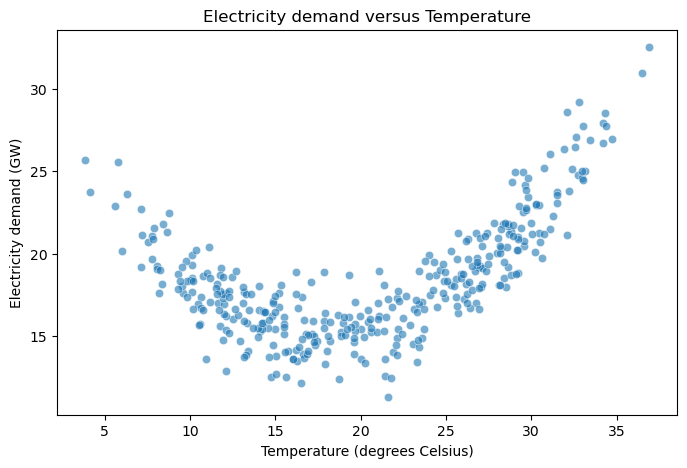

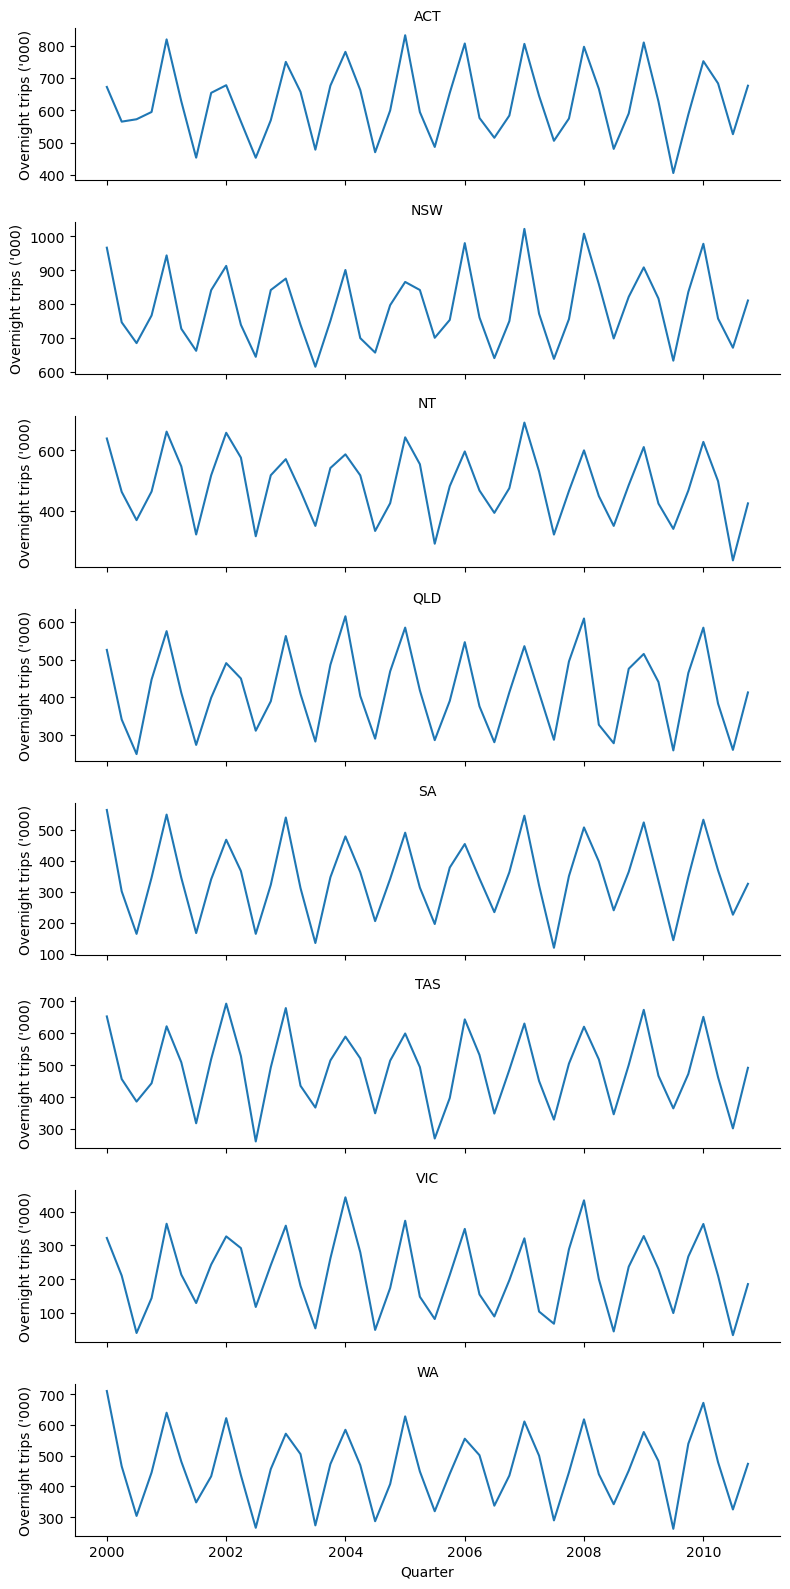

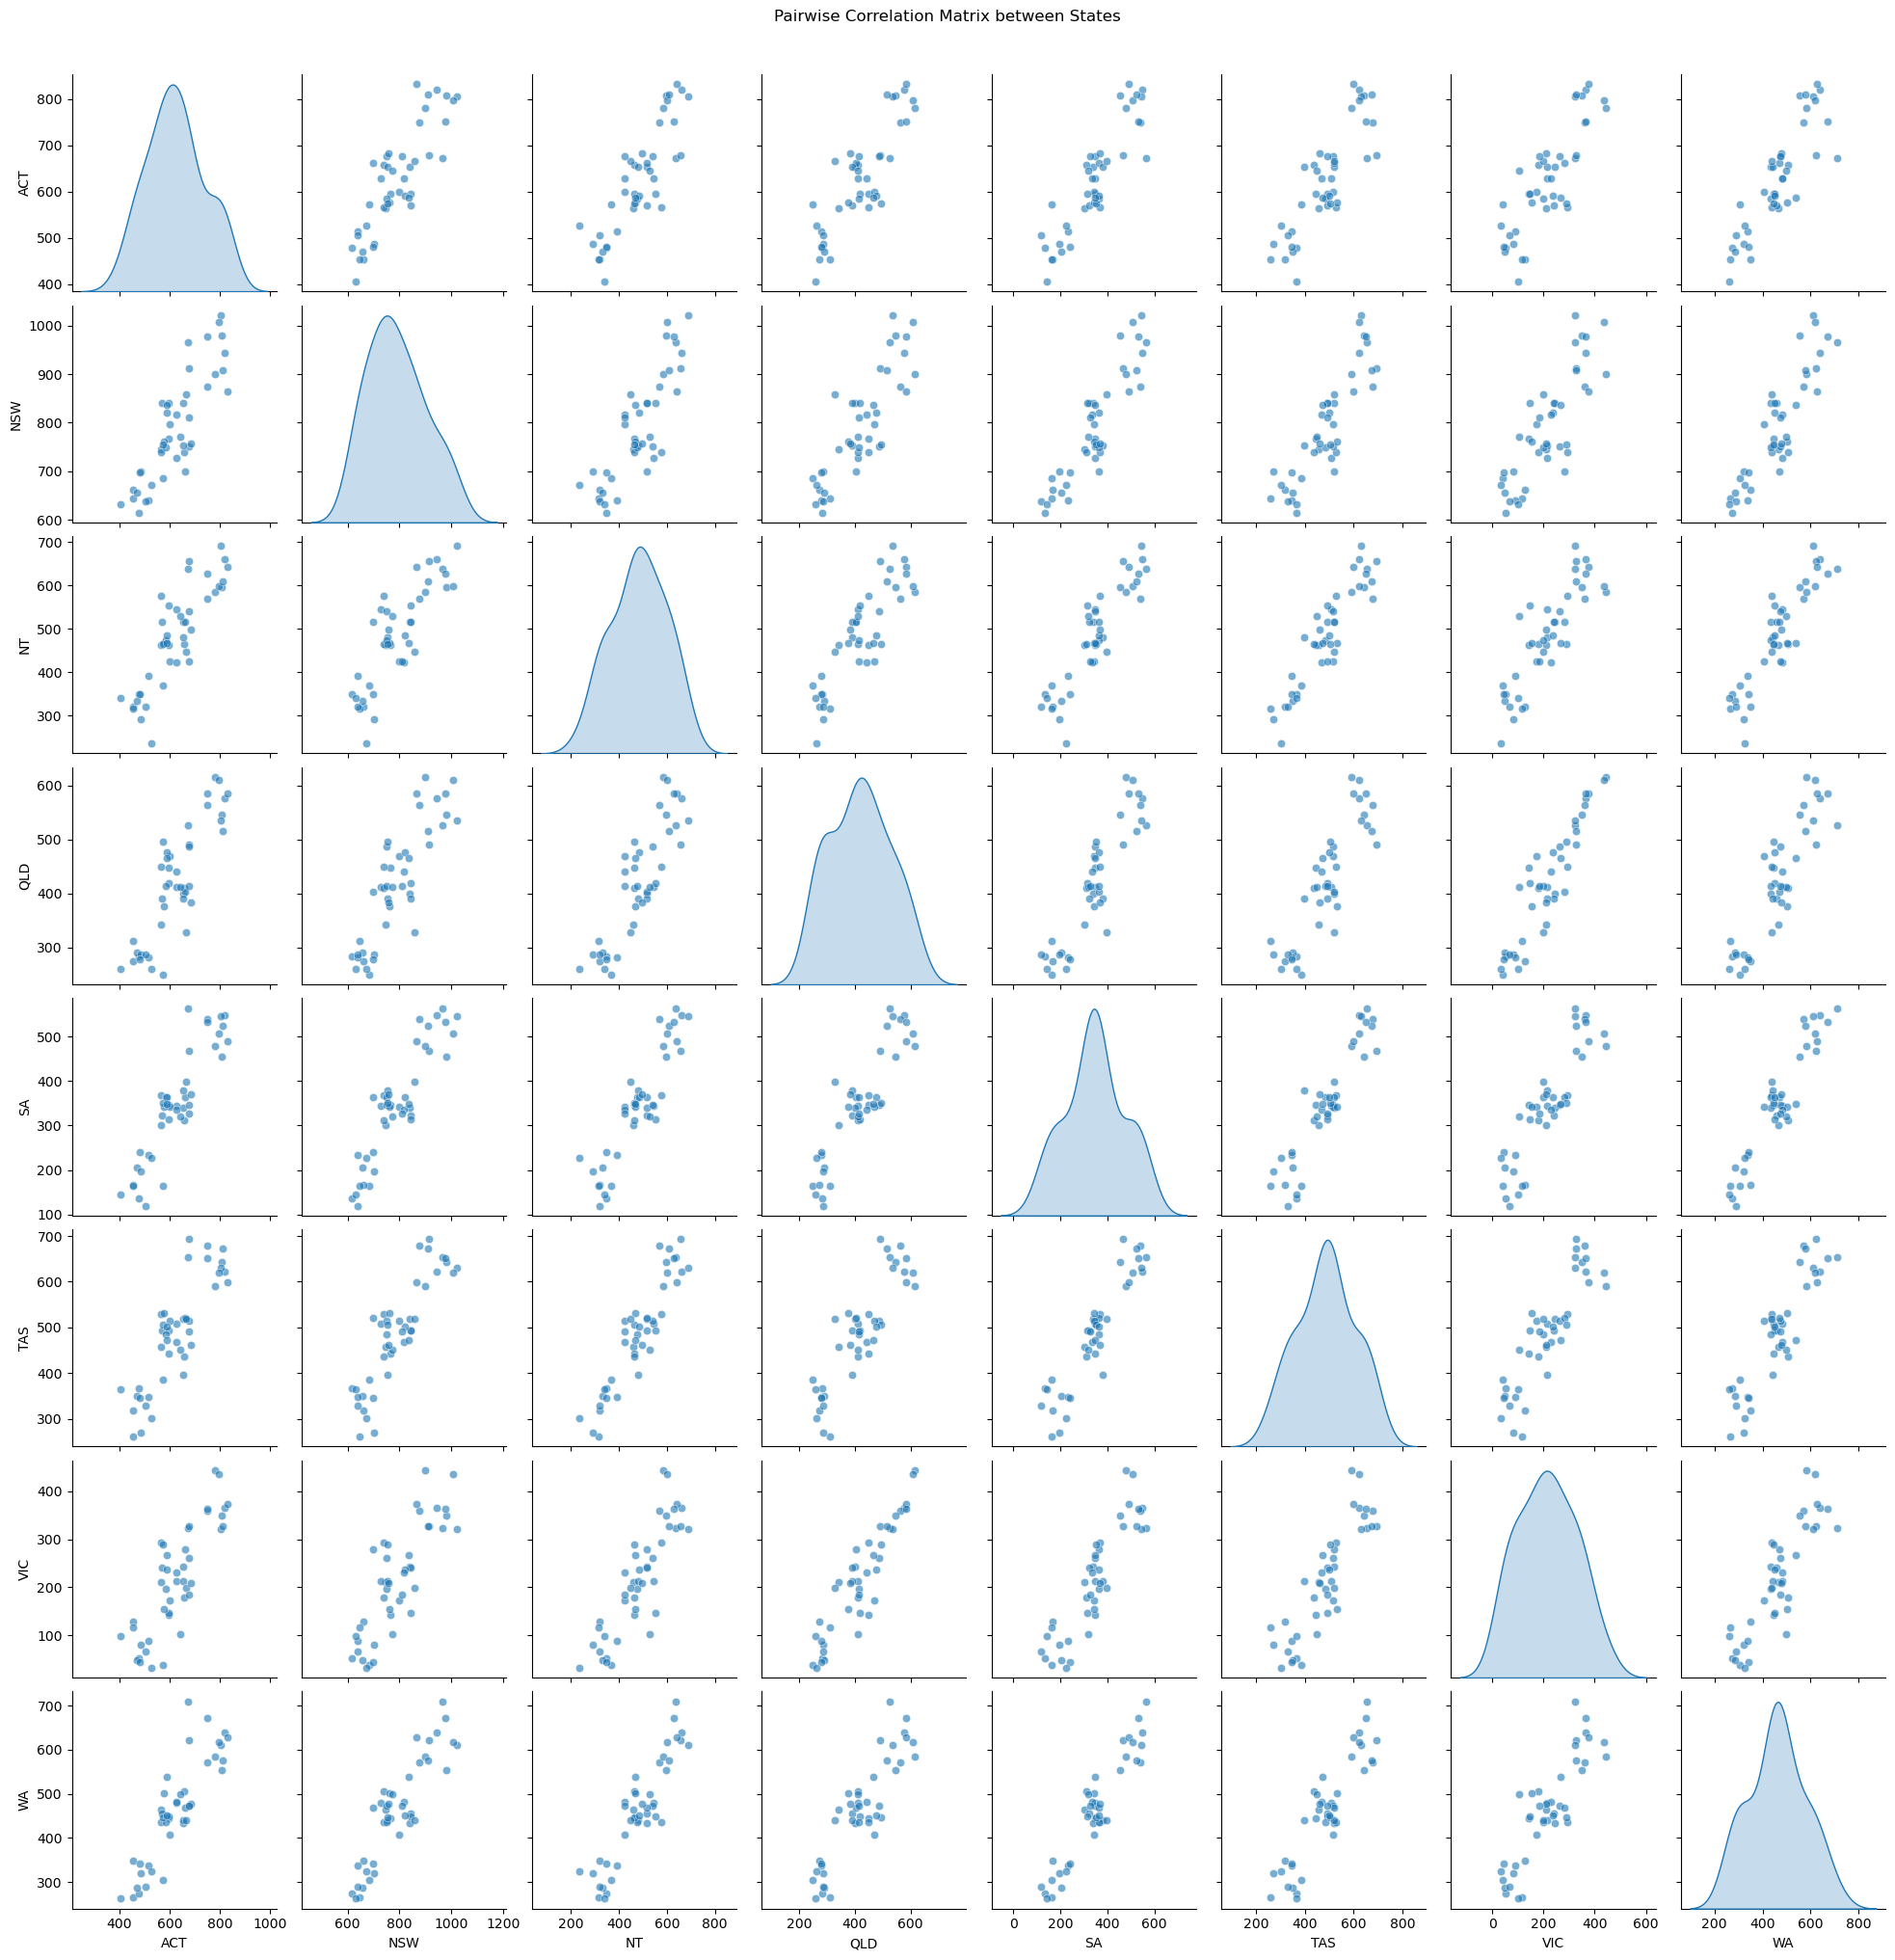

In [13]:
df = vic_elec_mock
# 1. Scatter Plot: Electricity demand vs Temperature (Replicates Snippet 5)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Temperature', y='Demand', alpha=0.6)
plt.title("Electricity demand versus Temperature")
plt.xlabel("Temperature (degrees Celsius)")
plt.ylabel("Electricity demand (GW)")
plt.show()

# 2. Faceted Line Plots (Replicates Snippet 6)
# R: facet_grid(vars(State), scales = "free_y")
g = sns.FacetGrid(visitors, row='State', sharey=False, aspect=4, height=2)
g.map_dataframe(sns.lineplot, x='Date', y='Trips')
g.set_titles(row_template="{row_name}")
g.set_axis_labels("Quarter", "Overnight trips ('000)")
plt.tight_layout()
plt.show()

# 3. Pairwise Scatterplot Matrix / Pairs Plot (Replicates Snippet 7)
# R: GGally::ggpairs(columns = 2:9)
# Select specific columns/States from your pivoted dataframe to check cross-correlation
sns.pairplot(pivoted_visitors.iloc[:, 0:8], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle("Pairwise Correlation Matrix between States", y=1.02)
plt.show()

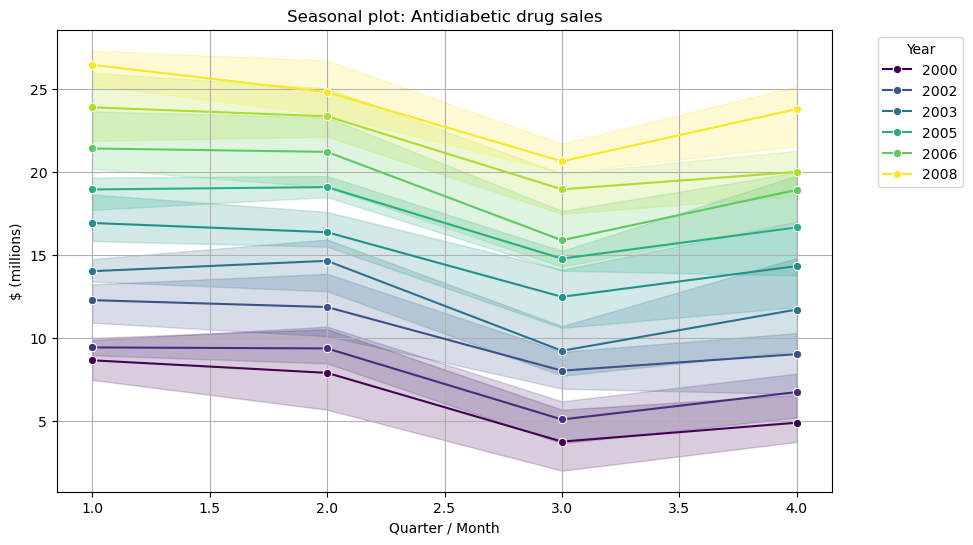

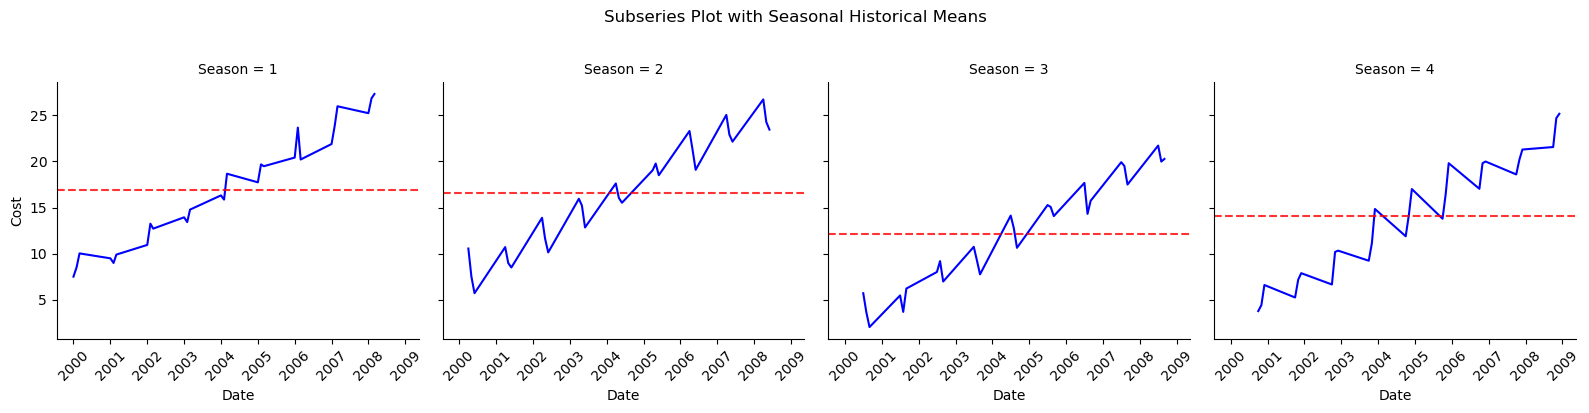

In [15]:
# Create explicit temporal tracking features for seasonal plots
df_recent = a10_mock.copy()
df_recent['Year'] = df_recent['Date'].dt.year
# Use .dt.quarter for quarterly data, or .dt.month / dt.strftime('%b') for monthly data
df_recent['Season'] = df_recent['Date'].dt.quarter 

# 1. Seasonal Plot (Replicates Snippet 2 & 4)
# R: gg_season(Cost, labels = "both")
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_recent, x='Season', y='Cost', hue='Year', palette='viridis', marker='o')
plt.title("Seasonal plot: Antidiabetic drug sales")
plt.xlabel("Quarter / Month")
plt.ylabel("$ (millions)")
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# 2. Seasonal Subseries Plot (Replicates Snippet 3)
# R: gg_subseries(Cost)
# In Python, we facet by the season/month and draw time trends with blue lines and means with a red line
g = sns.FacetGrid(df_recent, col='Season', sharey=True, col_wrap=4, height=4)
g.map_dataframe(sns.lineplot, x='Date', y='Cost', color='blue')

# Compute and overlay horizontal lines representing historical mean for each specific season
for ax, (_, sub_df) in zip(g.axes.flat, df_recent.groupby('Season')):
    season_mean = sub_df['Cost'].mean()
    ax.axhline(season_mean, color='red', linestyle='--', alpha=0.8, label=f'Mean: {season_mean:.1f}')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Subseries Plot with Seasonal Historical Means", y=1.02)
plt.tight_layout()
plt.show()

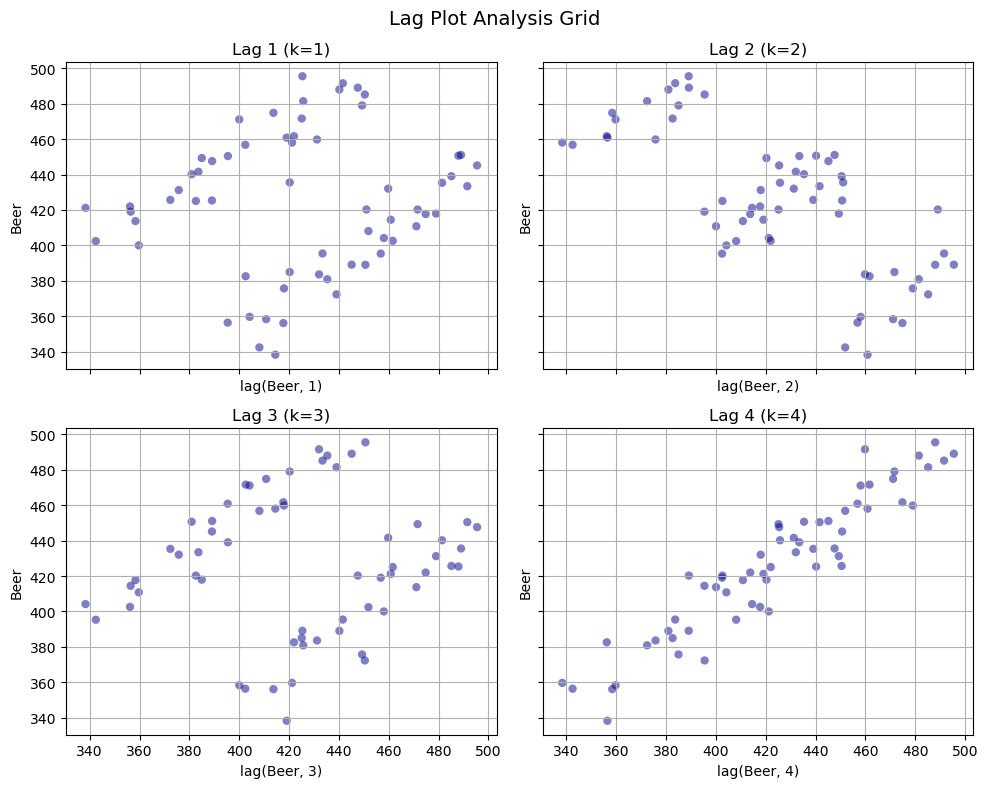

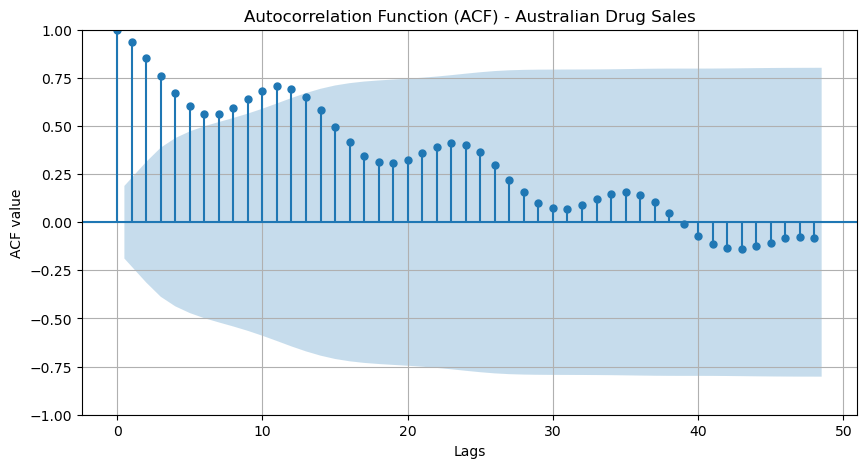

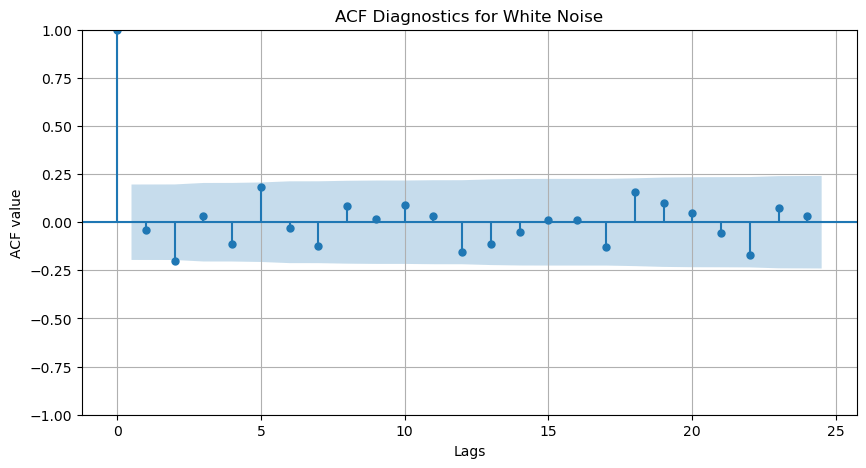

In [20]:
from statsmodels.graphics.tsaplots import plot_acf
df_recent = aus_production_mock.copy()
# 1. Lag Grid Plot (Replicates Snippet 8)
# R: gg_lag(Beer, geom = "point")
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes, start=1):
    # Shift time series down by i periods to map lag(t-i) vs original series(t)
    ax.scatter(df_recent['Beer'].shift(i), df_recent['Beer'], alpha=0.5, edgecolors='none', c='darkblue')
    ax.set_title(f"Lag {i} (k={i})")
    ax.set_xlabel(f"lag(Beer, {i})")
    ax.set_ylabel("Beer")
    ax.grid(True)

plt.suptitle("Lag Plot Analysis Grid", fontsize=14)
plt.tight_layout()
plt.show()

# 2. Autocorrelation Function (ACF) Plot (Replicates Snippet 9 & 10)
# R: a10 |> ACF(Cost, lag_max = 48) |> autoplot()
# Drop missing values caused by lagging / processing steps before running statsmodels ACF
#clean_series = df_recent['Cost'].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
# plot_acf plots the correlation coefficients along with the blue 95% confidence interval boundaries
plot_acf(a10_mock['Cost'].dropna(), lags=48, ax=ax, alpha=0.05, missing='drop')
ax.set_title("Autocorrelation Function (ACF) - Australian Drug Sales")
ax.set_xlabel("Lags")
ax.set_ylabel("ACF value")
plt.grid(True)
plt.show()

# 3. White Noise Check (Replicates Snippet 11)
# R: y |> ACF(wn) |> autoplot()
# For pure White Noise, 95% of spikes should stay inside the blue shaded critical threshold area.
white_noise_series = np.random.normal(loc=0, scale=1, size=100)

fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(white_noise_series, lags=24, ax=ax, alpha=0.05)
ax.set_title("ACF Diagnostics for White Noise")
ax.set_xlabel("Lags")
ax.set_ylabel("ACF value")
plt.grid(True)
plt.show()

In [21]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose, STL

np.random.seed(42)

# 1. aus_retail mock data
months_retail = pd.date_range(start="2000-01-01", periods=120, freq="MS")
aus_retail = pd.DataFrame({
    'Month': months_retail,
    'Industry': np.random.choice(["Newspaper and book retailing", "Other"], 120),
    'Turnover': np.random.uniform(10, 100, 120)
})

# 2. global_economy mock data
years_econ = pd.date_range(start="1970-01-01", end="2020-01-01", freq="YS").year
global_economy = pd.DataFrame({
    'Year': years_econ,
    'Code': np.repeat(["AUS", "USA", "CAN"], len(years_econ))[:len(years_econ)],
    'GDP': np.random.uniform(1e11, 1e12, len(years_econ))
})

# 3. aus_production mock data
quarters_prod = pd.date_range(start="1980-01-01", periods=80, freq="QS")
aus_production = pd.DataFrame({
    'Quarter': quarters_prod,
    'Gas': np.linspace(10, 50, 80) * np.random.uniform(0.8, 1.2, 80) # variance scales with trend
})

# 4. us_retail_employment mock data
months_emp = pd.date_range(start="1990-01-01", periods=144, freq="MS")
trend_pattern = np.linspace(2000, 3500, 144)
seasonal_pattern = 150 * np.sin(2 * np.pi * months_emp.month / 12)
noise = np.random.normal(0, 30, 144)

us_retail_employment = pd.DataFrame({
    'Month': months_emp,
    'Employed': trend_pattern + seasonal_pattern + noise
})
# Set index to datetime for decomposition tracking
us_retail_employment.set_index('Month', inplace=True, drop=False)

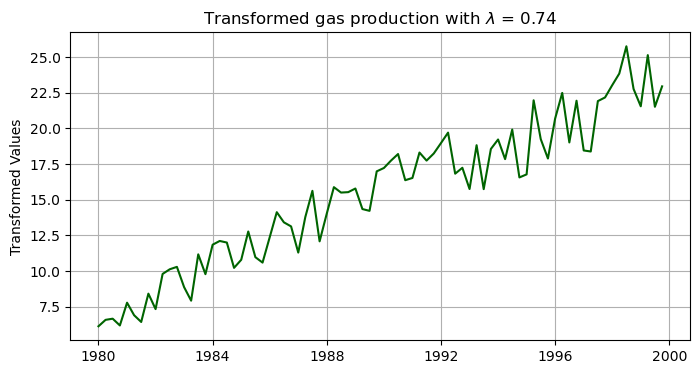

In [22]:
# 1. Annual Resampling & Subsetting (Replicates Snippet 1 & 2)
# R: index_by(Year = year(Month)) |> summarise(Turnover = sum(Turnover))
print_retail = aus_retail[aus_retail['Industry'] == "Newspaper and book retailing"].copy()
print_retail['Year'] = print_retail['Month'].dt.year

# Aggregate by Year using group_by logic
print_retail = print_retail.groupby(['Industry', 'Year'])['Turnover'].sum().reset_index()

aus_economy = global_economy[global_economy['Code'] == "AUS"]

# 2. Automated Box-Cox Box Transformations (Guerrero Optimization) (Replicates Snippet 3)
# R: features(Gas, features = guerrero) |> pull(lambda_guerrero)
# Scipy's boxcox function with lmbda=None automatically uses the maximum likelihood method (similar to Guerrero) 
# to find the optimal variance-stabilizing lambda parameter.
transformed_gas, optimal_lambda = stats.boxcox(aus_production['Gas'])

# Plotting Transformed Data
plt.figure(figsize=(8, 4))
plt.plot(aus_production['Quarter'], transformed_gas, color='darkgreen')
plt.title(f"Transformed gas production with $\\lambda$ = {optimal_lambda:.2f}")
plt.ylabel("Transformed Values")
plt.grid(True)
plt.show()

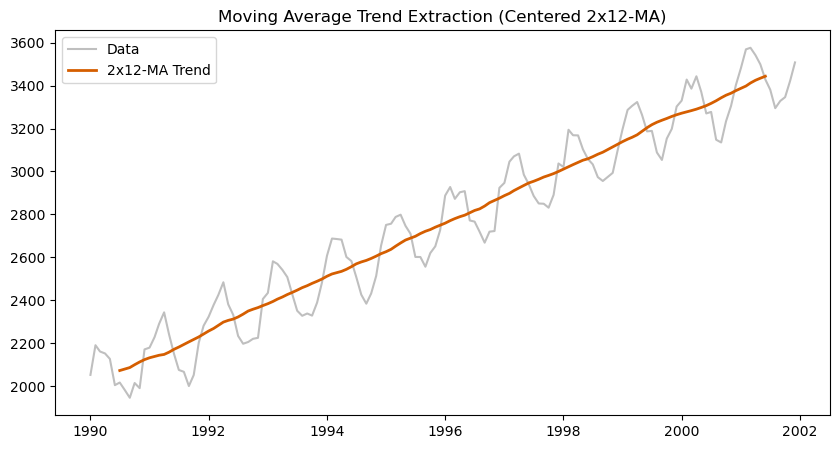

In [23]:
# Centered Moving Averages for Even-Length Periods (Replicates Snippet 5)
# To find a centered average for quarterly (4) or monthly (12) cycles, we must compute a 2-stage window.
us_retail_employment_ma = us_retail_employment.copy()

# Step A: 12-MA (R equivalent: .before = 5, .after = 6)
# Python rolls backward by default. We use a window size of 12.
us_retail_employment_ma['12-MA'] = us_retail_employment_ma['Employed'].rolling(window=12, min_periods=12).mean()

# Step B: Center the data using a 2-MA (R equivalent: 2x12-MA)
# This removes structural timing lag by shifting values halfway back
us_retail_employment_ma['2x12-MA'] = us_retail_employment_ma['12-MA'].rolling(window=2).mean().shift(-6)

# Visualization of Raw Data vs. Extracted Trend Component
plt.figure(figsize=(10, 5))
plt.plot(us_retail_employment_ma['Month'], us_retail_employment_ma['Employed'], color='gray', alpha=0.5, label='Data')
plt.plot(us_retail_employment_ma['Month'], us_retail_employment_ma['2x12-MA'], color='#D55E00', linewidth=2, label='2x12-MA Trend')
plt.title("Moving Average Trend Extraction (Centered 2x12-MA)")
plt.legend()
plt.show()

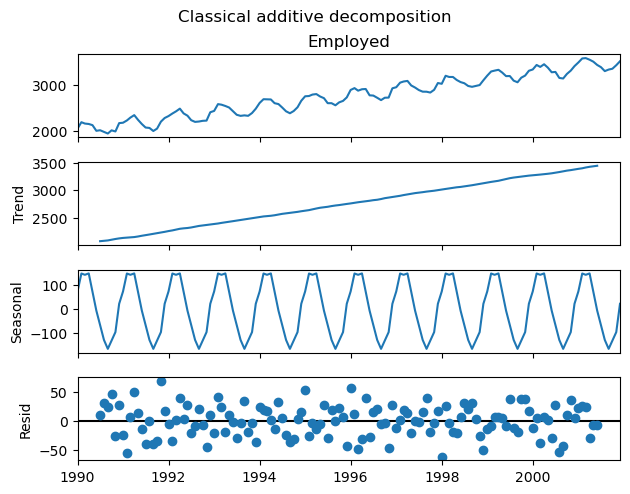

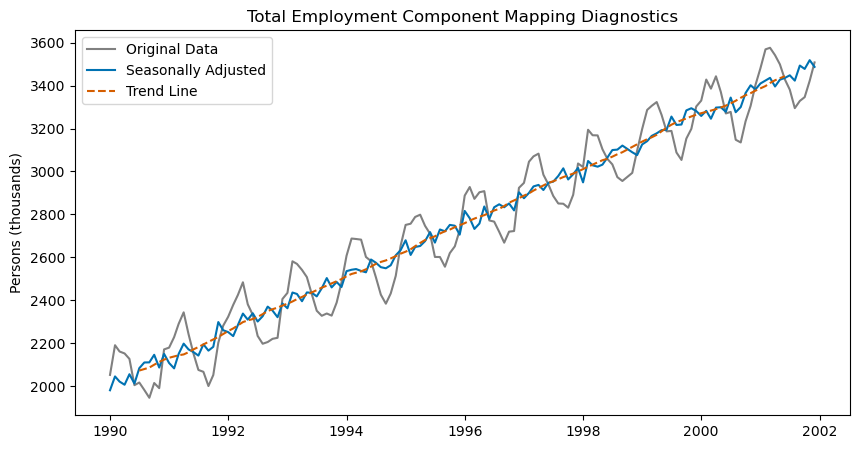

ValueError: trend must be an odd positive integer >= 3 where trend > period

In [ ]:
# 1. Classical Additive Decomposition (Replicates Snippet 6)
# R: classical_decomposition(Employed, type = "additive")
classical_dcmp = seasonal_decompose(us_retail_employment['Employed'], model='additive', period=12)

# Quick native plot showing: Observed, Trend, Seasonal, and Residuals (Resid)
fig = classical_dcmp.plot()
fig.suptitle("Classical additive decomposition", y=1.02)
plt.show()

# 2. Extracting Seasonally Adjusted Data (Replicates Snippet 4 & 8)
# Formula: Seasonally Adjusted = Original Data - Seasonal Component
us_retail_employment['season_adjust'] = us_retail_employment['Employed'] - classical_dcmp.seasonal
us_retail_employment['trend'] = classical_dcmp.trend

# Overlaying Data vs. Adjusted Components
plt.figure(figsize=(10, 5))
plt.plot(us_retail_employment['Month'], us_retail_employment['Employed'], color='gray', label='Original Data')
plt.plot(us_retail_employment['Month'], us_retail_employment['season_adjust'], color='#0072B2', label='Seasonally Adjusted')
plt.plot(us_retail_employment['Month'], us_retail_employment['trend'], color='#D55E00', linestyle='--', label='Trend Line')
plt.title("Total Employment Component Mapping Diagnostics")
plt.ylabel("Persons (thousands)")
plt.legend()
plt.show()

# 3. STL Decomposition (Seasonal and Trend decomposition using Loess) (Replicates Snippet 10)
# R: STL(Employed ~ trend(window = 7) + season(window = "periodic"), robust = True)
# Parameter mapping lookup for exams:
# 'period' = base cycle speed (12 for monthly)
# 'trend' = length of the trend loess window (must be an odd integer)
# 'seasonal' = length of seasonal window. To match 'periodic', use an extremely large odd number or omit window changes.
stl_model = STL(us_retail_employment['Employed'], period=12, trend=7, seasonal=1001, robust=True)
stl_dcmp = stl_model.fit()


fig_stl = stl_dcmp.plot()
fig_stl.suptitle("Robust STL Loess Decomposition Plot", y=1.02)
plt.show()